#### Quick tutorial for navigating running LoSSETT and its outputs

This notebook reads in HEALPix ERA5 data from the DKRZ mirror using the `intake` package.

A guide to working with HEALPix data can be found at the [`easy.gems` documentation page](https://easy.gems.dkrz.de/Processing/healpix/)

In [1]:
# 1. Load requisite packages and ignore warnings for cleaner output
import numpy as np
import xarray as xr
import warnings
import intake
import healpy
from lossett.calc.calc_inter_scale_transfers import calc_inter_scale_energy_transfer_kinetic
import datetime as dt

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

##### NOTE this part is only needed as we are reading in HEALPix data. Currently LoSSETT requires data to be on a regular horizontal grid.

In [2]:
# 2. The nextGEMS function to convert HEALPix data to lat-lon. LoSSETT v0.2 requires lat-lon input.
def get_nn_lon_lat_index(nside, lons, lats):
    lons2, lats2 = np.meshgrid(lons, lats)
    return xr.DataArray(
        healpy.ang2pix(nside, lons2, lats2, nest=True, lonlat=True),
        coords=[("latitude", lats), ("longitude", lons)],
    )

In [3]:
# 3. Read in the remotely hosted HEALPix data
cat = intake.open_catalog('https://digital-earths-global-hackathon.github.io/catalog/catalog.yaml')['online']

sim = cat['ERA5']
zoom = 7 # Zoom=6 is about 1 deg
ds = sim(zoom=zoom).to_dask() 

In [4]:
# Quick look at the data we've just read in
ds

<xarray.Dataset> Size: 545GB
Dimensions:  (time: 1008, cell: 196608, level: 37)
Coordinates:
  * time     (time) datetime64[ns] 8kB 1940-01-01 1940-02-01 ... 2023-12-01
  * cell     (cell) float32 786kB 0.0 1.0 2.0 ... 1.966e+05 1.966e+05 1.966e+05
    lat      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
    lon      (cell) float32 786kB dask.array<chunksize=(196608,), meta=np.ndarray>
  * level    (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
    crs      float32 4B ...
Data variables: (12/111)
    100u     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    100v     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10fg     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10si     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10u      (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    10v      (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    ...       ...
    uvb      (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
    v        (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    vo       (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    w        (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    z        (time, level, cell) float32 29GB dask.array<chunksize=(24, 4, 4096), meta=np.ndarray>
    zust     (time, cell) float32 793MB dask.array<chunksize=(24, 16384), meta=np.ndarray>
Attributes:
    acknowledgment:  Contains modified Copernicus Climate Change Service info...
    contact:         lukas.kluft@mpimet.mpg.de
    creator:         Lukas Kluft
    description:     HEALPixelation of ERA5
    source:          Post-processed dataset based on the ERA5 mirror located ...

In [5]:
# 3. HEALPix data when converted to lat-lon has to be interpolated for smooth
# solutions using supersampling. Numbers here will need to be adjusted for 
# different zoom levels. This is to acquire 1 deg ERA5 data as an input to LoSSETT.
supersampling = {"longitude": 4, "latitude": 4}

idx = get_nn_lon_lat_index(
    2**zoom, 
    np.linspace(-180, 180, supersampling['longitude']*180), 
    np.linspace(-90, 90, supersampling['latitude']*90)
)

In [6]:
# 4. Create u,v,w arrays. Here, we are just filling an empty array for w since it has to be w in m s-1, and the ERA5
# default is omega in Pa s-1. This is a trivial conversion, but we don't do it here to save memory and run time.
# This example is just looking at one day (the first day of DYAMOND Summer) to save time, but this time can be as long as you like.
u_lon_lat = ds.u.isel(cell=idx).sel(time=slice(dt.datetime(2016,8,1),dt.datetime(2016,8,1))).coarsen(supersampling).mean()
v_lon_lat = ds.v.isel(cell=idx).sel(time=slice(dt.datetime(2016,8,1),dt.datetime(2016,8,1))).coarsen(supersampling).mean()
w_lon_lat = xr.zeros_like(u_lon_lat)
w_lon_lat.name='w'

In [111]:
# Quick sanity check of the data
u_lon_lat

<xarray.DataArray 'u' (time: 1, level: 37, latitude: 180, longitude: 360)> Size: 10MB
dask.array<mean_agg-aggregate, shape=(1, 37, 180, 360), dtype=float32, chunksize=(1, 4, 1, 360), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 8B 1940-01-01
  * level      (level) float32 148B 1.0 2.0 3.0 5.0 ... 925.0 950.0 975.0 1e+03
  * latitude   (latitude) float64 1kB -89.62 -88.62 -87.62 ... 87.62 88.62 89.62
  * longitude  (longitude) float64 3kB -179.6 -178.6 -177.6 ... 178.6 179.6
    cell       (latitude, longitude) float32 259kB 1.638e+05 ... 3.686e+04
    lat        (latitude, longitude) float32 259kB dask.array<chunksize=(34, 360), meta=np.ndarray>
    lon        (latitude, longitude) float32 259kB dask.array<chunksize=(34, 360), meta=np.ndarray>
    crs        float32 4B ...
Attributes:
    grid_mapping:   crs
    levtype:        isobaricInhPa
    long_name:      U component of wind
    standard_name:  eastward_wind
    units:          m s**-1

##### `ds_u_3D` is created by merging the $(u,v,w)$ files (or, equally, extracting these variables from a dataset with a lot of variables).

In [7]:
# 5. Create the 'ds_u_3D' input file that LoSSETT looks for.
ds_u_3D = xr.merge([u_lon_lat, v_lon_lat, w_lon_lat])
ds_u_3D = ds_u_3D.rename({'level':'pressure'})
plevs = [10,70,100,150,200,250,300,400,500,600,700,850,925] # Random selection of pressure levels concentrating around the tropopause
ds_u_3D = ds_u_3D.sel(pressure=plevs).compute()
# ds_u_3D

In [8]:
control_dict = {
    "max_r": 10.0, # Maximum radius in degrees that we want our kernel to occupy
    "max_r_units": "deg",
    "angle_precision": 1e-10,
    "x_coord_name": "longitude",
    "x_coord_units": "deg",
    "x_coord_boundary": "periodic", # (Global ERA5 data)
    "y_coord_name": "latitude",
    "y_coord_units": "deg",
    "y_coord_boundary": np.nan
}

In [9]:
# 6. Choose the length scales we want saved in the output
length_scales = np.array(
    [110,220,330,500,640,800,1000,1250,1600,2000,2500,3200,4000,5000]
)
length_scales = 1000.0 * length_scales # convert to m; ensure float

In [10]:
# 7. Calculate kinetic DR indicator - this runs LoSSETT on the data. May take some time and create a lot of print statements.
Dl_u = calc_inter_scale_energy_transfer_kinetic(
    ds_u_3D, control_dict,
    length_scales=length_scales
)

# ensure correct dimension ordering
Dl_u = Dl_u.transpose("length_scale","time","pressure","latitude","longitude")




################################################################################
### LoSSETT vn. 0.2 ############################################################
### Function: calc_inter_scale_energy_transfer_kinetic #########################
################################################################################

Input data attributes: {'grid_mapping': 'crs', 'levtype': 'isobaricInhPa', 'long_name': 'U component of wind', 'standard_name': 'eastward_wind', 'units': 'm s**-1'}

min. allowed \ell = 2.206e+05 m

max. allowed \ell = 6.618e+05 m

length_scales =  [330000. 500000. 640000.]



Calculating angular integral for r=0 km to r=1103 km

Current memory usage: 2.07147 GB



r = 0

 <xarray.DataArray 'delta_u_cubed' (angle: 1, latitude: 90, time: 1,
                                   pressure: 13, longitude: 180)> Size: 842kB
array([[[[[nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
          [nan, nan, nan, ..., nan, nan, nan],
         

In [127]:
# Take a look around the data. Some plotting examples follow.
Dl_u

<xarray.DataArray 'Dl_u' (length_scale: 3, time: 1, pressure: 13, latitude: 90,
                          longitude: 180)> Size: 5MB
array([[[[[ 3.19602291e-08,  1.46108185e-08,  5.43464912e-11, ...,
           -5.89231955e-11,  4.86810486e-08,  4.45670354e-08],
          [ 5.36563806e-10,  8.50000824e-10,  8.67244877e-10, ...,
           -3.50118894e-10,  4.00326606e-10,  1.07445107e-09],
          [ 1.69025186e-06,  2.43932264e-06,  2.18804956e-06, ...,
           -2.34366570e-07,  3.71169918e-07,  1.20657902e-06],
          ...,
          [-2.35385948e-09, -2.05066236e-09, -1.82364938e-09, ...,
           -3.94473940e-09, -3.59853749e-09, -3.19413179e-09],
          [-4.55432415e-11, -9.35935217e-12,  1.17487569e-12, ...,
           -6.02793649e-12, -7.77325079e-11, -3.89519501e-11],
          [-9.09474098e-09, -2.86295817e-09,  8.15354024e-14, ...,
           -3.20847318e-10, -1.46110533e-08, -9.72197137e-09]],

         [[-1.03209223e-10, -9.73684979e-12,  1.82847499e-12, ...,
           -1.79845217e-11, -1.86487014e-10, -6.45813792e-11],
          [-2.21224081e-11,  1.48630396e-11,  2.32865906e-11, ...,
           -2.24879287e-11, -5.58887281e-11, -8.23203370e-12],
          [ 2.64185374e-08,  8.72126314e-08,  1.01336610e-07, ...,
           -5.95387579e-08, -4.67015028e-08, -3.57415771e-09],
...
          [-1.09136666e-06, -9.95496448e-07, -9.05526966e-07, ...,
           -1.22900973e-06, -1.14800385e-06, -1.10301668e-06],
          [-2.36761561e-08, -1.44059165e-08, -8.65139205e-09, ...,
           -3.06477007e-08, -2.51257751e-08, -9.23932240e-09],
          [-8.18814760e-07, -7.05528260e-07, -5.07960809e-07, ...,
           -1.35278150e-06, -1.49021690e-06, -6.35754449e-07]],

         [[ 1.26923782e-07,  8.56703000e-08,  4.32145706e-08, ...,
            1.87223644e-07,  1.46968845e-07,  4.41167445e-08],
          [-4.42141277e-08, -7.67183928e-08, -6.61249706e-08, ...,
           -3.70651276e-08, -7.01599766e-08, -6.45700844e-08],
          [ 6.13272112e-06,  6.58090382e-06,  5.89108572e-06, ...,
            3.09537029e-06,  4.16245243e-06,  5.65703387e-06],
          ...,
          [-9.71024994e-07, -8.74711974e-07, -7.85514004e-07, ...,
           -1.16225283e-06, -1.08608109e-06, -1.02390670e-06],
          [-1.88433791e-08, -1.11179253e-08, -6.63602320e-09, ...,
           -2.38344158e-08, -1.90687235e-08, -7.27997148e-09],
          [-7.09816332e-07, -6.11620824e-07, -4.40219256e-07, ...,
           -1.17334765e-06, -1.29105621e-06, -5.50359455e-07]]]]])
Coordinates:
  * length_scale  (length_scale) float64 24B 3.3e+05 5e+05 6.4e+05
  * time          (time) datetime64[ns] 8B 2016-08-01
  * pressure      (pressure) float32 52B 10.0 70.0 100.0 ... 700.0 850.0 925.0
  * latitude      (latitude) float64 720B -89.25 -87.24 -85.24 ... 87.24 89.25
  * longitude     (longitude) float64 1kB -179.2 -177.2 -175.2 ... 177.2 179.2
    cell          (latitude, longitude) float32 65kB 1.639e+05 ... 3.685e+04
    lat           (latitude, longitude) float32 65kB -88.99 -89.04 ... 88.99
    lon           (latitude, longitude) float32 65kB 202.9 203.2 ... 156.8 168.6
    crs           float32 4B 0.0
Attributes:
    long_name:              inter_scale_transfer_of_kinetic_energy
    units:                  m2 s-3
    description:            Transfer of kinetic energy (density) across a len...
    sign_convention:        Positive to smaller scales.
    LoSSETT_version:        0.2
    input_data_attributes:  {'grid_mapping': 'crs', 'levtype': 'isobaricInhPa...

##### (Very) quick plotting examples

1. Map. This example is at 850 hPa (lowest level of the free troposphere). There are topography effects around Greenland and Antarctica, upscale under the stratiform cloud bands, and downscale at the base of the ITCZ due to convective convergence. See [McKinnon-Gray et al. (2026)](https://arxiv.org/abs/2510.25444) for a deeper dive into understanding the phenomena associated with interscale energy transfer (ISET) in the tropics. Interesting patch of strong ISET across Africa and off the east coast. Probably a combination of orographic effects and the strong monsoon flow.

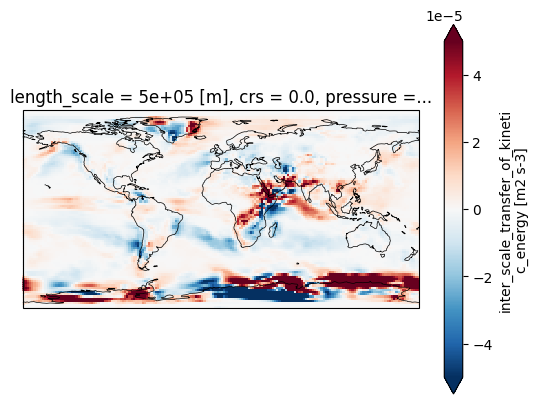

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})

Dl_u.sel(pressure=850, length_scale=500000).plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=-5e-5,
    vmax=5e-5,
    cmap='RdBu_r'
)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

2. Zonally averaged latitude-height plot. Here we can see strong downscale associated with the winter hemisphere jet. In August this is the southern hemisphere subtropical jet. Those strong orographic effects can be seen near Antarctica, as well as an interesting dipole in the SH stratospheric polar vortex. There is weaker signals of downscale in the NH jet at about 50N. It is still there, just not as strong! Also upscale at convective outflow region of ITCZ at tropopause accompanied by the downscale at lower levels which we also saw in the map.

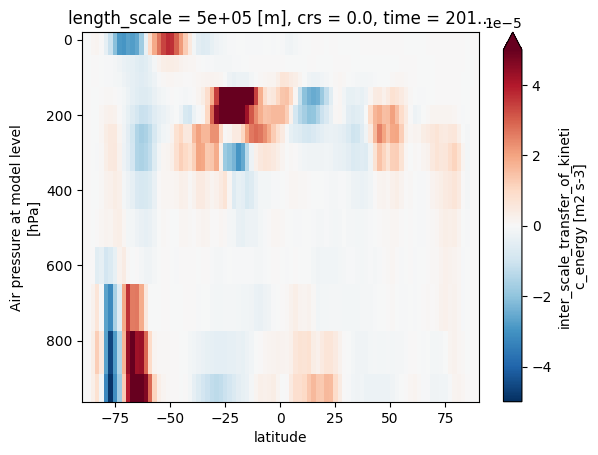

In [21]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1)
Dl_u.sel(length_scale=500000).mean(dim='longitude').plot(vmin=-5e-5,vmax=5e-5,cmap='RdBu_r',ax=ax)
ax.invert_yaxis()

3. Longitude-height slice at the equator. Here we can see downscale signature from the tropical easterly jet at upper levels (part of the Walker Circulation). The upscale signature from the monsoon slow can be seen at 50E (just off the east African coast). The upscale signature above it is probably also part of the monsoon circulation. There are also convectively coupled Kelvin waves over the Indian Ocean at this time, so the upscale signature at upper levels may be to do with this. Lots to explore..!

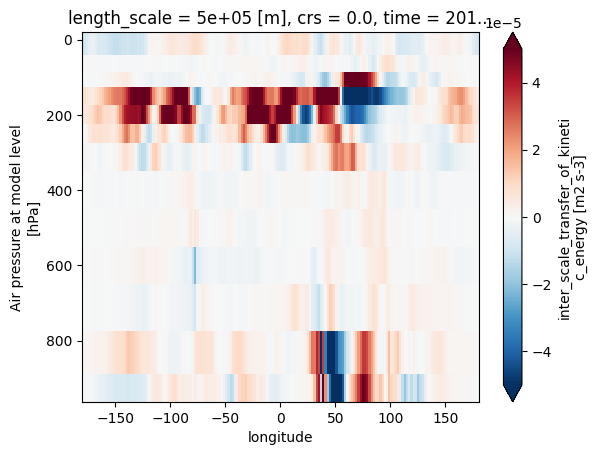

In [16]:
fig,ax=plt.subplots(1,1)
Dl_u.sel(latitude=0,length_scale=500000,method='nearest').plot(vmin=-5e-5,vmax=5e-5,cmap='RdBu_r')
ax.invert_yaxis()